## Week 13: Text Analysis

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

import nltk
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

In [20]:
df = pd.read_csv('data13_LabeledNewsData.csv', encoding = 'ISO-8859-1')
df.sample(5)

,datetime,headline,ticker,sentiment
6624,8/9/19 4:57,$SNMP .54 down 67% EXTREMELY OVERSOLD!????????...,PFE,0
4104,2/23/19 17:28,"INTL BUS. MACH. DL-,20 $IBM Is Yet to See Tra...",IBM,1
1178,12/16/19 15:31,#Boeing to Temporarily Shut Down 737 Max Produ...,BA,0
7808,11/26/18 18:29,United Technologies to separate into three com...,UTX,1
8033,6/12/19 14:22,"Richard T. Burke Sells 10,000 Shares of United...",UNH,0


In [24]:
y = df['sentiment']
text = df['headline']
text_train, text_test, y_train, y_test = train_test_split(text, y, test_size = 0.25, random_state = 101)
text_test.sample(3)

2324    Coca-Cola Consolidated $COKE Upgraded to Sell ...
6616    $PFE $MYL:10 Cheap Dividend Stocks to Load Up On:
6193    $MSFT broke a new historic high of $140.67 on ...
Name: headline, dtype: object

In [28]:
bw = CountVectorizer(lowercase = True, stop_words = 'english')
bw.fit(text_train)
dtm_train = bw.transform(text_train)
dtm_test = bw.transform(text_test)

              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1029
           1       0.91      0.93      0.92      1339

    accuracy                           0.91      2368
   macro avg       0.91      0.91      0.91      2368
weighted avg       0.91      0.91      0.91      2368



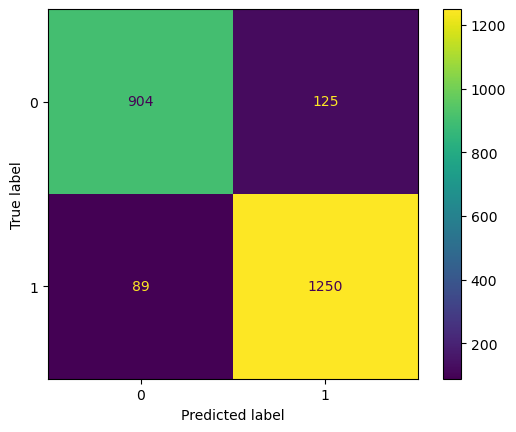

In [30]:
nb = MultinomialNB()
nb.fit(dtm_train, y_train)
y_pred = nb.predict(dtm_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(nb, dtm_test, y_test)

In [34]:
tfidf = TfidfVectorizer(lowercase = True, stop_words = 'english')
dtm_train = tfidf.fit_transform(text_train)
dtm_test = tfidf.transform(text_test)

              precision    recall  f1-score   support

           0       0.94      0.79      0.86      1029
           1       0.86      0.96      0.91      1339

    accuracy                           0.89      2368
   macro avg       0.90      0.88      0.88      2368
weighted avg       0.89      0.89      0.89      2368



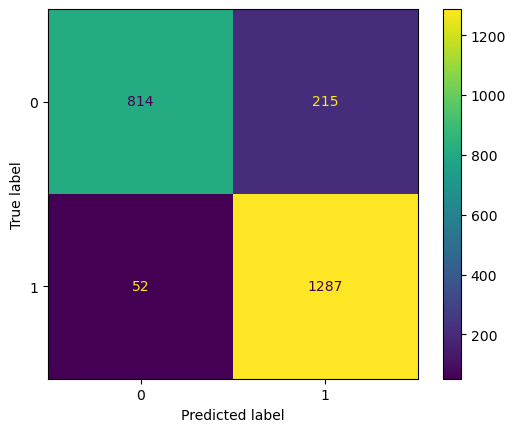

In [36]:
nb = MultinomialNB()
nb.fit(dtm_train, y_train)
y_pred = nb.predict(dtm_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(nb, dtm_test, y_test)